# Feature Importance Analysis

This notebook analyzes the feature importance of Linear Regression, Random Forest, and Gradient Boosting models.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split

# Load Processed Data
train_df = pd.read_csv('../processed_train.csv')

# Ensure Sales is numeric and drop NaNs
train_df['Sales'] = pd.to_numeric(train_df['Sales'], errors='coerce')
train_df.dropna(subset=['Sales'], inplace=True)

# Select a subset of stores for demonstration/efficiency if needed, or use all
# For feature importance, using a sample of data is often sufficient to get the general trend
sample_df = train_df.sample(frac=0.1, random_state=42) # Using 10% of data for speed

# Handle missing values in features
sample_df = sample_df.fillna(0)

X = sample_df.drop(['Sales', 'Store'], axis=1)
y = sample_df['Sales']
X = X.select_dtypes(include=[np.number, bool]) # Ensure only numeric/bool features

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data loaded and split.")

Data loaded and split.


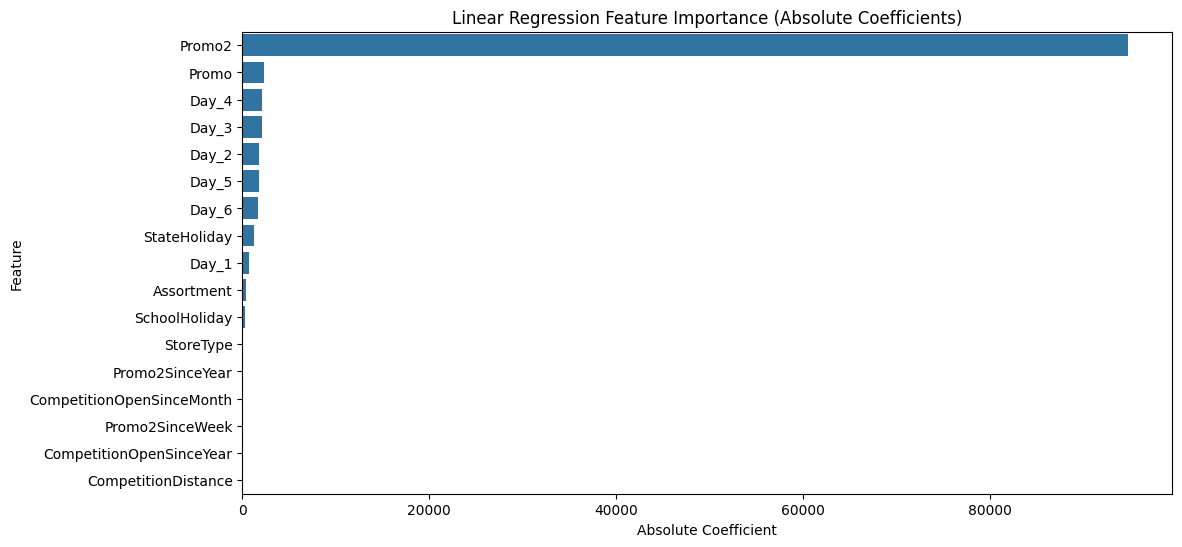

In [4]:
# Linear Regression Feature Importance (Coefficients)
lreg = LinearRegression()
lreg.fit(X_train, y_train)

coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lreg.coef_})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Abs_Coefficient', y='Feature', data=coef_df.head(20))
plt.title('Linear Regression Feature Importance (Absolute Coefficients)')
plt.xlabel('Absolute Coefficient')
plt.show()

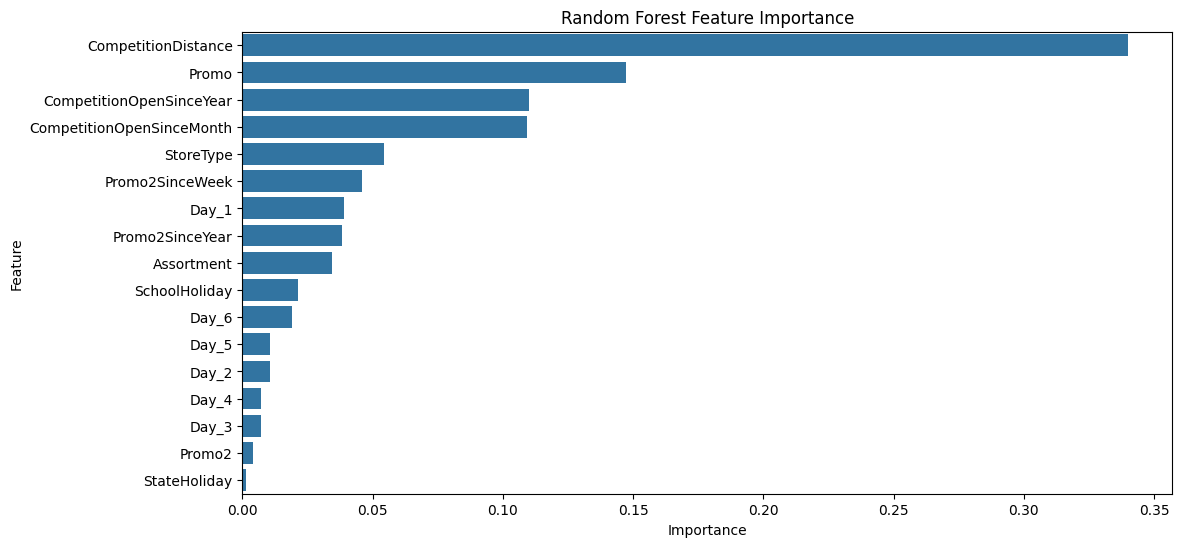

In [5]:
# Random Forest Feature Importance
# Reduced estimators for speed
rf_reg = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1) 
rf_reg.fit(X_train, y_train)

rf_importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf_reg.feature_importances_})
rf_importances = rf_importances.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importances.head(20))
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.show()

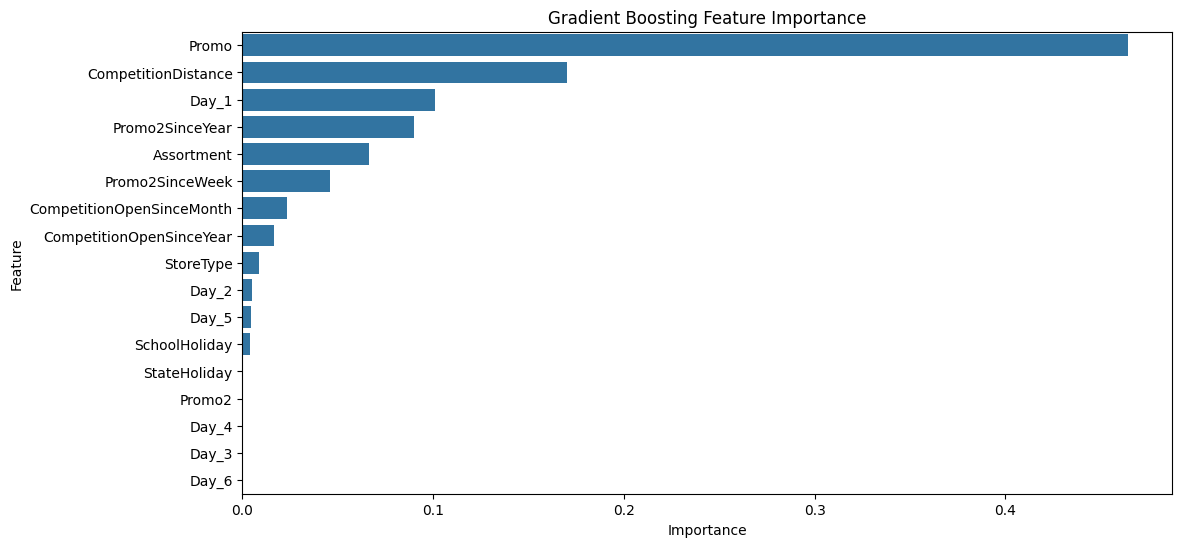

In [6]:
# Gradient Boosting Feature Importance
xgb_reg = GradientBoostingRegressor(n_estimators=50, random_state=42)
xgb_reg.fit(X_train, y_train)

xgb_importances = pd.DataFrame({'Feature': X.columns, 'Importance': xgb_reg.feature_importances_})
xgb_importances = xgb_importances.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=xgb_importances.head(20))
plt.title('Gradient Boosting Feature Importance')
plt.xlabel('Importance')
plt.show()

In [7]:
# Comparative Analysis of Top Features

top_n = 5
print(f"Top {top_n} Features by Model:")

print("\nLinear Regression:")
print(coef_df.head(top_n)['Feature'].tolist())

print("\nRandom Forest:")
print(rf_importances.head(top_n)['Feature'].tolist())

print("\nGradient Boosting:")
print(xgb_importances.head(top_n)['Feature'].tolist())

Top 5 Features by Model:

Linear Regression:
['Promo2', 'Promo', 'Day_4', 'Day_3', 'Day_2']

Random Forest:
['CompetitionDistance', 'Promo', 'CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth', 'StoreType']

Gradient Boosting:
['Promo', 'CompetitionDistance', 'Day_1', 'Promo2SinceYear', 'Assortment']
